## Rechargable PowerStream Battery Capacity Recreation

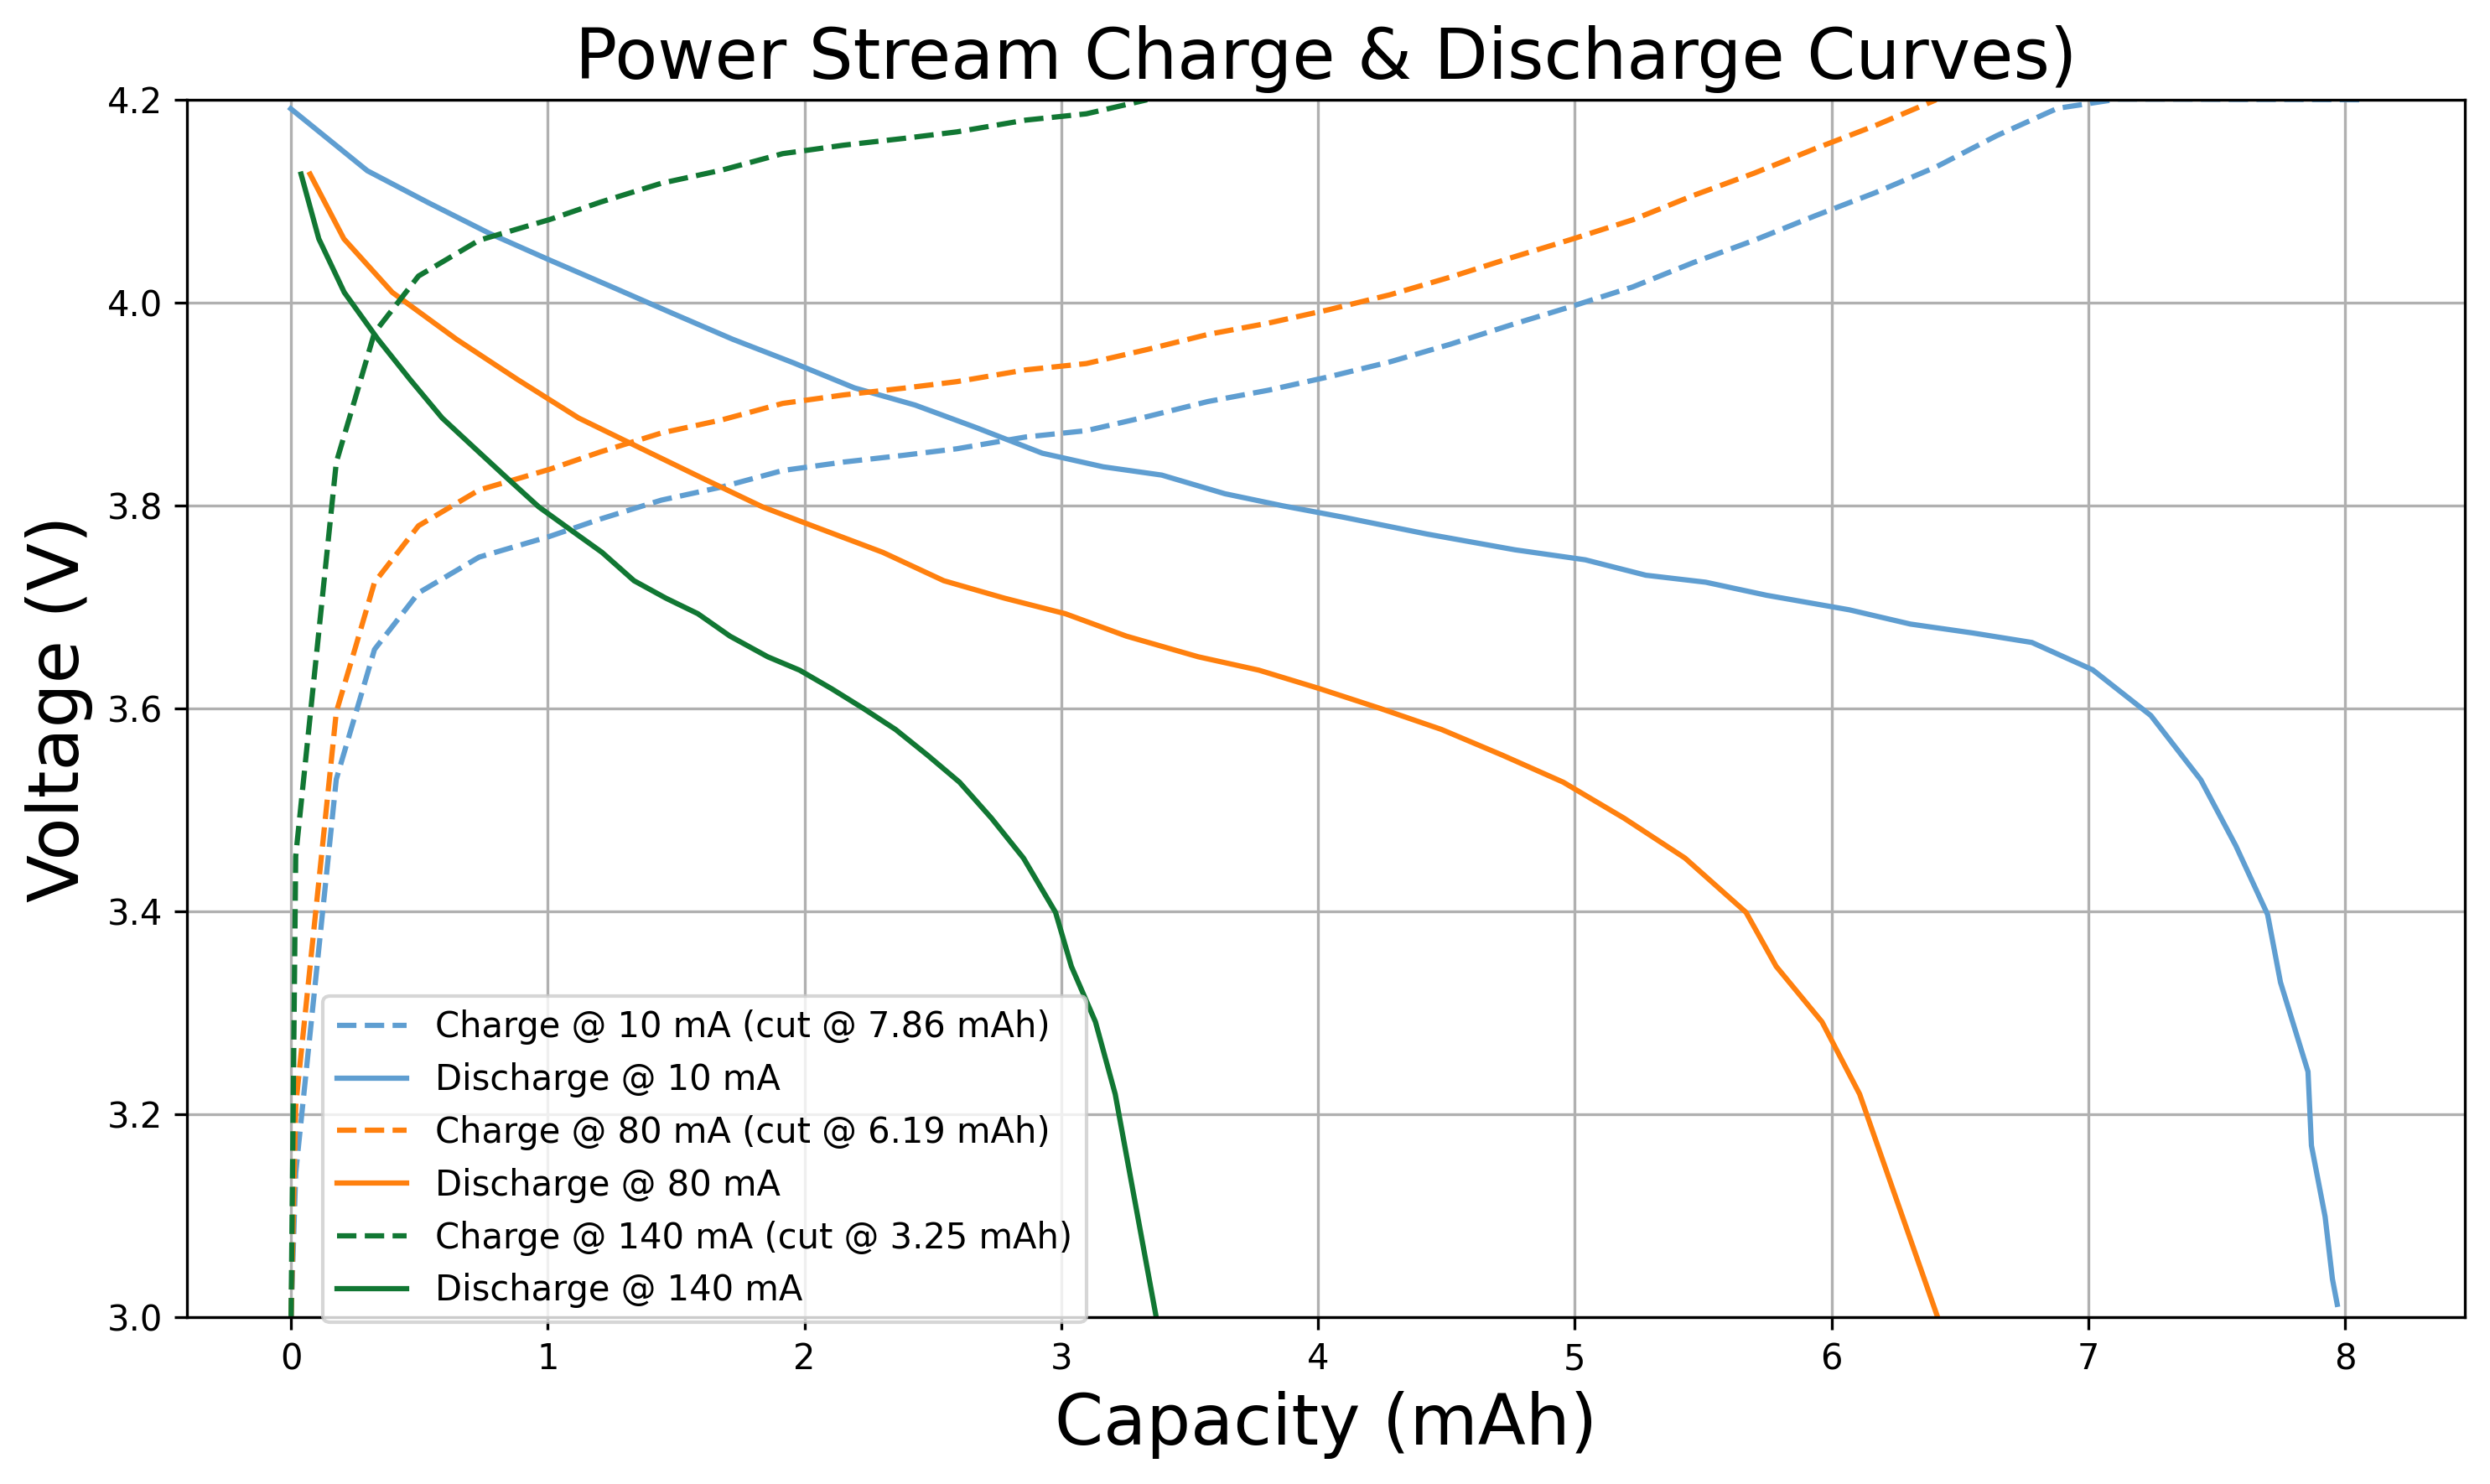

/tmp/ipykernel_2699/2230525751.py:129: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_mWh = np.trapz(Vc, Qc)


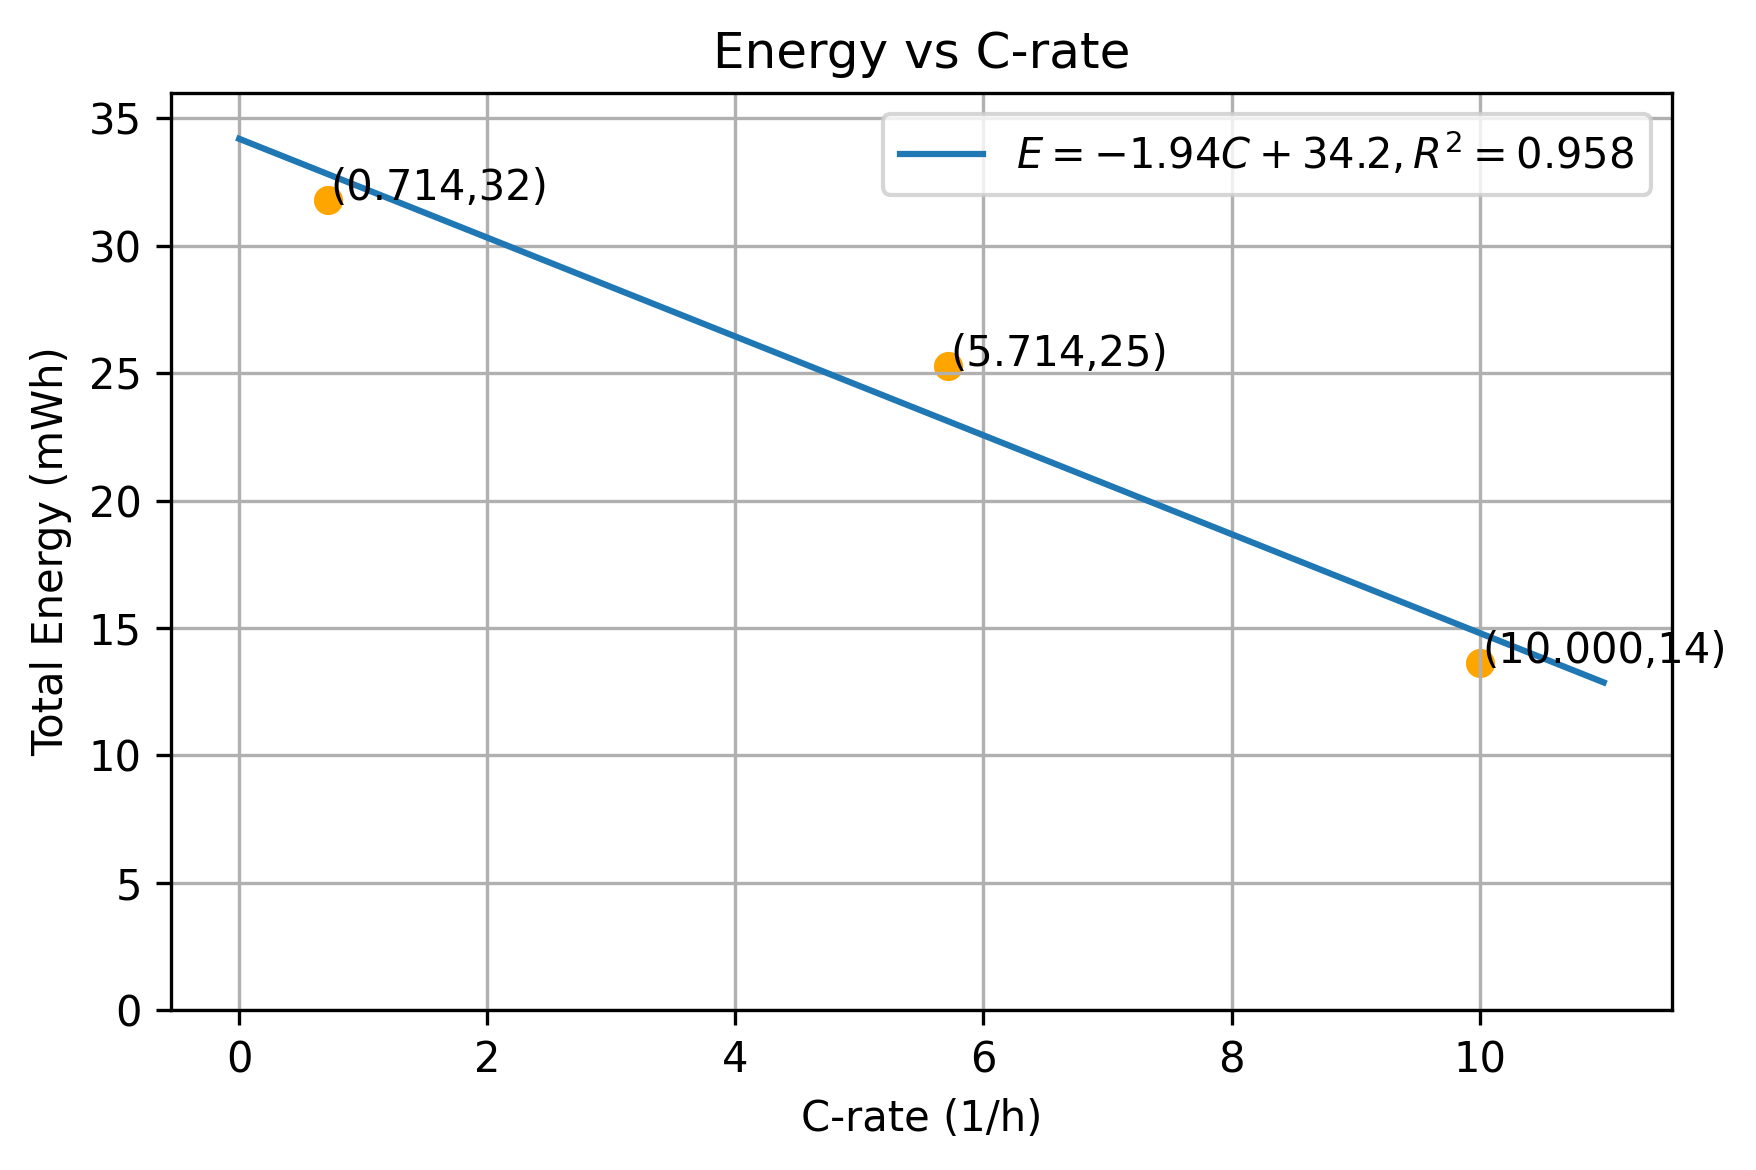

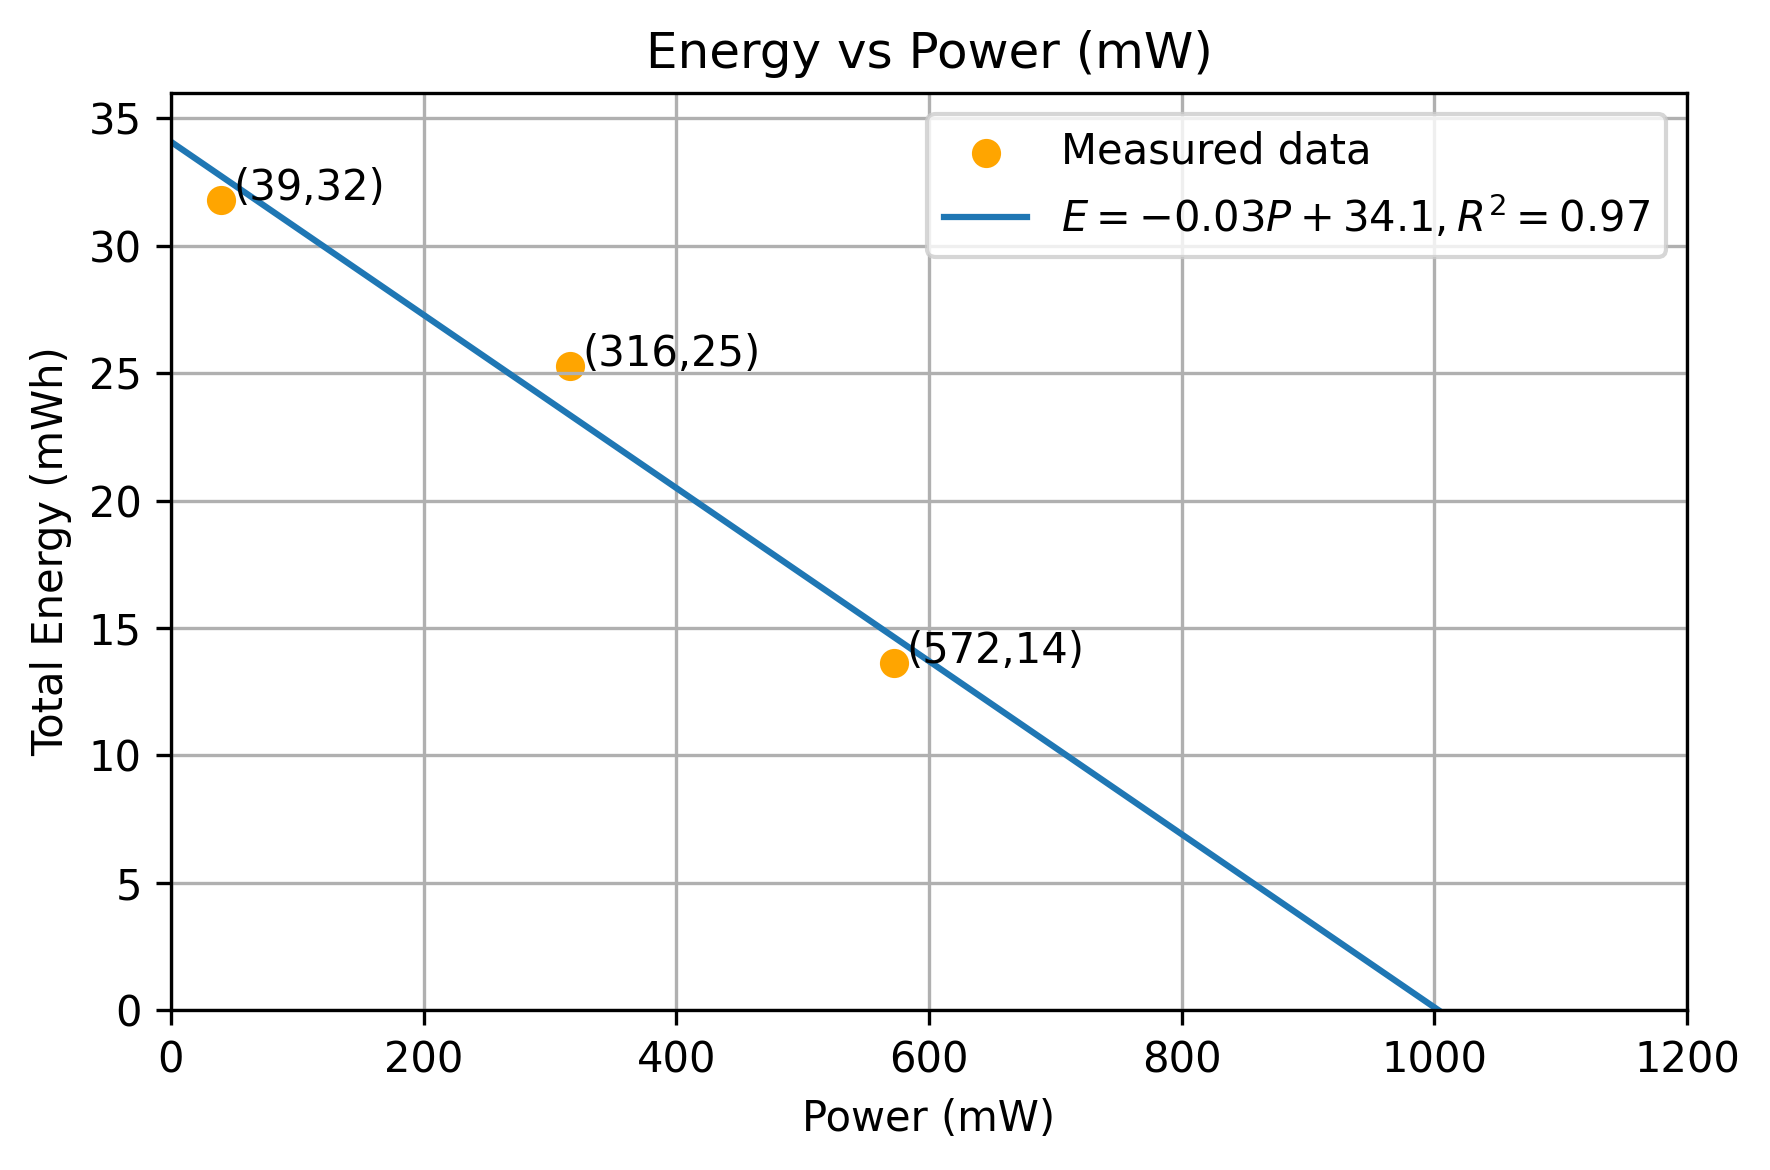

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1) URLs ────────────────────────────────────────────────────────────────────
url_charge_10    = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSjV0Z-Mqvci52rrlN_1v86oQoX2VNLeVQsQXQGy-kbQIjOsan1U2UQN9gwFMAGSzS-b3S_NZfYLdoR/pub?gid=1003450434&single=true&output=csv"
url_discharge_10 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSjV0Z-Mqvci52rrlN_1v86oQoX2VNLeVQsQXQGy-kbQIjOsan1U2UQN9gwFMAGSzS-b3S_NZfYLdoR/pub?gid=1452856388&single=true&output=csv"
url_discharge_80 = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSjV0Z-Mqvci52rrlN_1v86oQoX2VNLeVQsQXQGy-kbQIjOsan1U2UQN9gwFMAGSzS-b3S_NZfYLdoR/pub?gid=862036139&single=true&output=csv"

# ─── 2) Parameters ─────────────────────────────────────────────────────────────
norm_capacity   = 20.0    # mAh of the original 10 mA spec
target_capacity = 14.0    # mAh of the battery you want to model
scale           = target_capacity / norm_capacity
k_peuk          = 1.15    # exponent for Peukert’s adjustment at 140 mA
Vmin            = 3.0     # charge‐curve start voltage
Vmax            = 4.2     # plateau/cut voltage

# ─── 3) Load charge & discharge curves ────────────────────────────────────────
df_c10        = pd.read_csv(url_charge_10)
Q10_raw, V10  = df_c10.select_dtypes(include='number').iloc[:, :2].values.T
Q10           = Q10_raw * scale

df_d10        = pd.read_csv(url_discharge_10)
df_d80        = pd.read_csv(url_discharge_80)
Qd10_raw, Vd10 = df_d10.select_dtypes(include='number').iloc[:, :2].values.T
Qd80_raw, Vd80 = df_d80.select_dtypes(include='number').iloc[:, :2].values.T
Qd10, Qd80     = Qd10_raw * scale, Qd80_raw * scale

# estimate 140 mA discharge curve
C80   = Qd80_raw.max()
C140  = C80 * (80/140)**k_peuk
Qd140 = Qd80_raw * (C140/C80) * scale
Vd140 = np.append(Vd80, Vmin)
Qd140 = np.append(Qd140, Qd140[-1])

# ─── 4) Knee‐detection helpers ─────────────────────────────────────────────────
def find_knee(Q, V):
    """
    Return index of the 'knee' as the point of max
    perpendicular distance from the chord joining start→end.
    """
    p1 = np.array([Q[0],   V[0]])
    p2 = np.array([Q[-1],  V[-1]])
    chord = p2 - p1
    L = np.hypot(*chord)
    pts = np.vstack((Q, V)).T
    vecs = pts - p1
    # cross‐product magnitude / chord length gives perp. distance
    dists = np.abs(vecs[:,0]*chord[1] - vecs[:,1]*chord[0]) / L
    return np.argmax(dists), dists

def find_knee_end(Q, V, threshold_frac=0.5):
    """
    From the curve (Q,V), find:
      - the index of the max‐distance knee
      - then walk forward until the distance falls below threshold_frac * max_dist
    Returns that 'end_of_knee' index.
    """
    idx_max, dists = find_knee(Q, V)
    thr = threshold_frac * dists[idx_max]
    # scan forward for the first point below thr
    for i in range(idx_max+1, len(dists)):
        if dists[i] < thr:
            return i
    return len(Q)-1

def find_cut_end(Q_raw, V, scale, threshold_frac=0.5):
    """
    Returns the capacity (mAh) at the END of the knee, using scaled Q.
    """
    Qs = Q_raw * scale
    end_idx = find_knee_end(Qs, V, threshold_frac)
    return Qs[end_idx]

# compute a dictionary of cut‐points (10,80,140 mA)
cuts = {
    10:  find_cut_end(Qd10_raw, Vd10, scale, threshold_frac=0.5),
    80:  find_cut_end(Qd80_raw, Vd80, scale, threshold_frac=0.5),
    140: find_cut_end(Qd140/scale, Vd140, scale, threshold_frac=0.5),
}

# ─── 5) Build truncated charge curves (extend one extra point beyond cut) ─────
def simple_charge_curve(Qend):
    # find insertion index then include one extra point
    ins = np.searchsorted(Q10, Qend)
    end_idx = min(ins+1, len(Q10))
    Qc_raw = Q10[:end_idx]
    Vc_raw = V10[:end_idx]
    # drop any V > Vmax
    mask = Vc_raw <= Vmax
    Qc, Vc = Qc_raw[mask], Vc_raw[mask]
    # shift so last V hits Vmax and first hits Vmin
    Vc = Vc + (Vmax - Vc[-1])
    Vc[0] = Vmin
    return Qc, Vc

charge_curves = {I: simple_charge_curve(cuts[I]) for I in cuts}

# ─── 6) Plot charge vs discharge ──────────────────────────────────────────────
plt.figure(figsize=(10,6),dpi=300)
# Define a manual color scheme  |  ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF']
colors = {10:'#5F9ED1', 80:'#FF800E', 140:'#117733'}

for I in (10,80,140):
    Qc, Vc = charge_curves[I]
    plt.plot(Qc, Vc, '--', color=colors[I],
             label=f'Charge @ {I} mA (cut @ {cuts[I]:.2f} mAh)')
    if I == 10:
        plt.plot(Qd10, Vd10, '-', color=colors[I], label='Discharge @ 10 mA')
    elif I == 80:
        plt.plot(Qd80, Vd80, '-', color=colors[I], label='Discharge @ 80 mA')
    else:
        plt.plot(Qd140, Vd140, '-', color=colors[I], label='Discharge @ 140 mA')

plt.xlabel("Capacity (mAh)", fontsize=20)
plt.ylabel("Voltage (V)", fontsize=20)
plt.ylim(3.0, 4.2)
plt.title("Power Stream Charge & Discharge Curves)", fontsize=20)
plt.legend(loc='center left', bbox_to_anchor=(0.052, 0.13))
plt.grid(True)
plt.tight_layout()
plt.show()

# ─── 7) Compute energies, C‐rates, and average power ─────────────────────────
energies, C_rates, powers = [], [], []

for I in (10,80,140):
    Qc, Vc = charge_curves[I]
    E_mWh = np.trapz(Vc, Qc)
    energies.append(E_mWh)
    C_rates.append(I / target_capacity)
    t_h = Qc[-1] / I
    powers.append(E_mWh / t_h)

E_vals = np.array(energies)
C_vals = np.array(C_rates)
P_vals = np.array(powers)

# ─── 8) Linear fits & summary plots ───────────────────────────────────────────
mC, bC = np.polyfit(C_vals, E_vals, 1)
r2_C   = 1 - np.sum((E_vals - (mC*C_vals+bC))**2) / np.sum((E_vals - E_vals.mean())**2)
mP, bP = np.polyfit(P_vals, E_vals, 1)
r2_P   = 1 - np.sum((E_vals - (mP*P_vals+bP))**2) / np.sum((E_vals - E_vals.mean())**2)

# Energy vs C‐rate
plt.figure(figsize=(6,4),dpi=300)
plt.scatter(C_vals, E_vals, color='orange')
for c,e in zip(C_vals, E_vals):
    plt.text(c+0.02, e, f'({c:.3f},{e:.0f})')
xC = np.linspace(0, C_vals.max()*1.1, 100)
plt.plot(xC, mC*xC + bC, label=f'$E={mC:.2f}C+{bC:.1f}, R^2={r2_C:.3f}$', color="C0")
plt.xlabel("C‐rate (1/h)")
plt.ylabel("Total Energy (mWh)")
plt.ylim(0, 36)
plt.title("Energy vs C‐rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Energy vs Power
plt.figure(figsize=(6,4),dpi=300)
plt.scatter(P_vals, E_vals, color='orange', label='Measured data')
for p,e in zip(P_vals, E_vals):
    plt.text(p+10, e, f'({p:.0f},{e:.0f})')
xP = np.linspace(0, 1200, 100)
plt.plot(xP, mP*xP + bP, label=f'$E={mP:.2f}P+{bP:.1f}, R^2={r2_P:.2f}$', color="C0")
plt.xlim(0, 1200)
plt.xlabel("Power (mW)")
plt.ylabel("Total Energy (mWh)")
plt.ylim(0, 36)
plt.title("Energy vs Power (mW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Non-rechargable PowerStream Battery Capacity Recreation

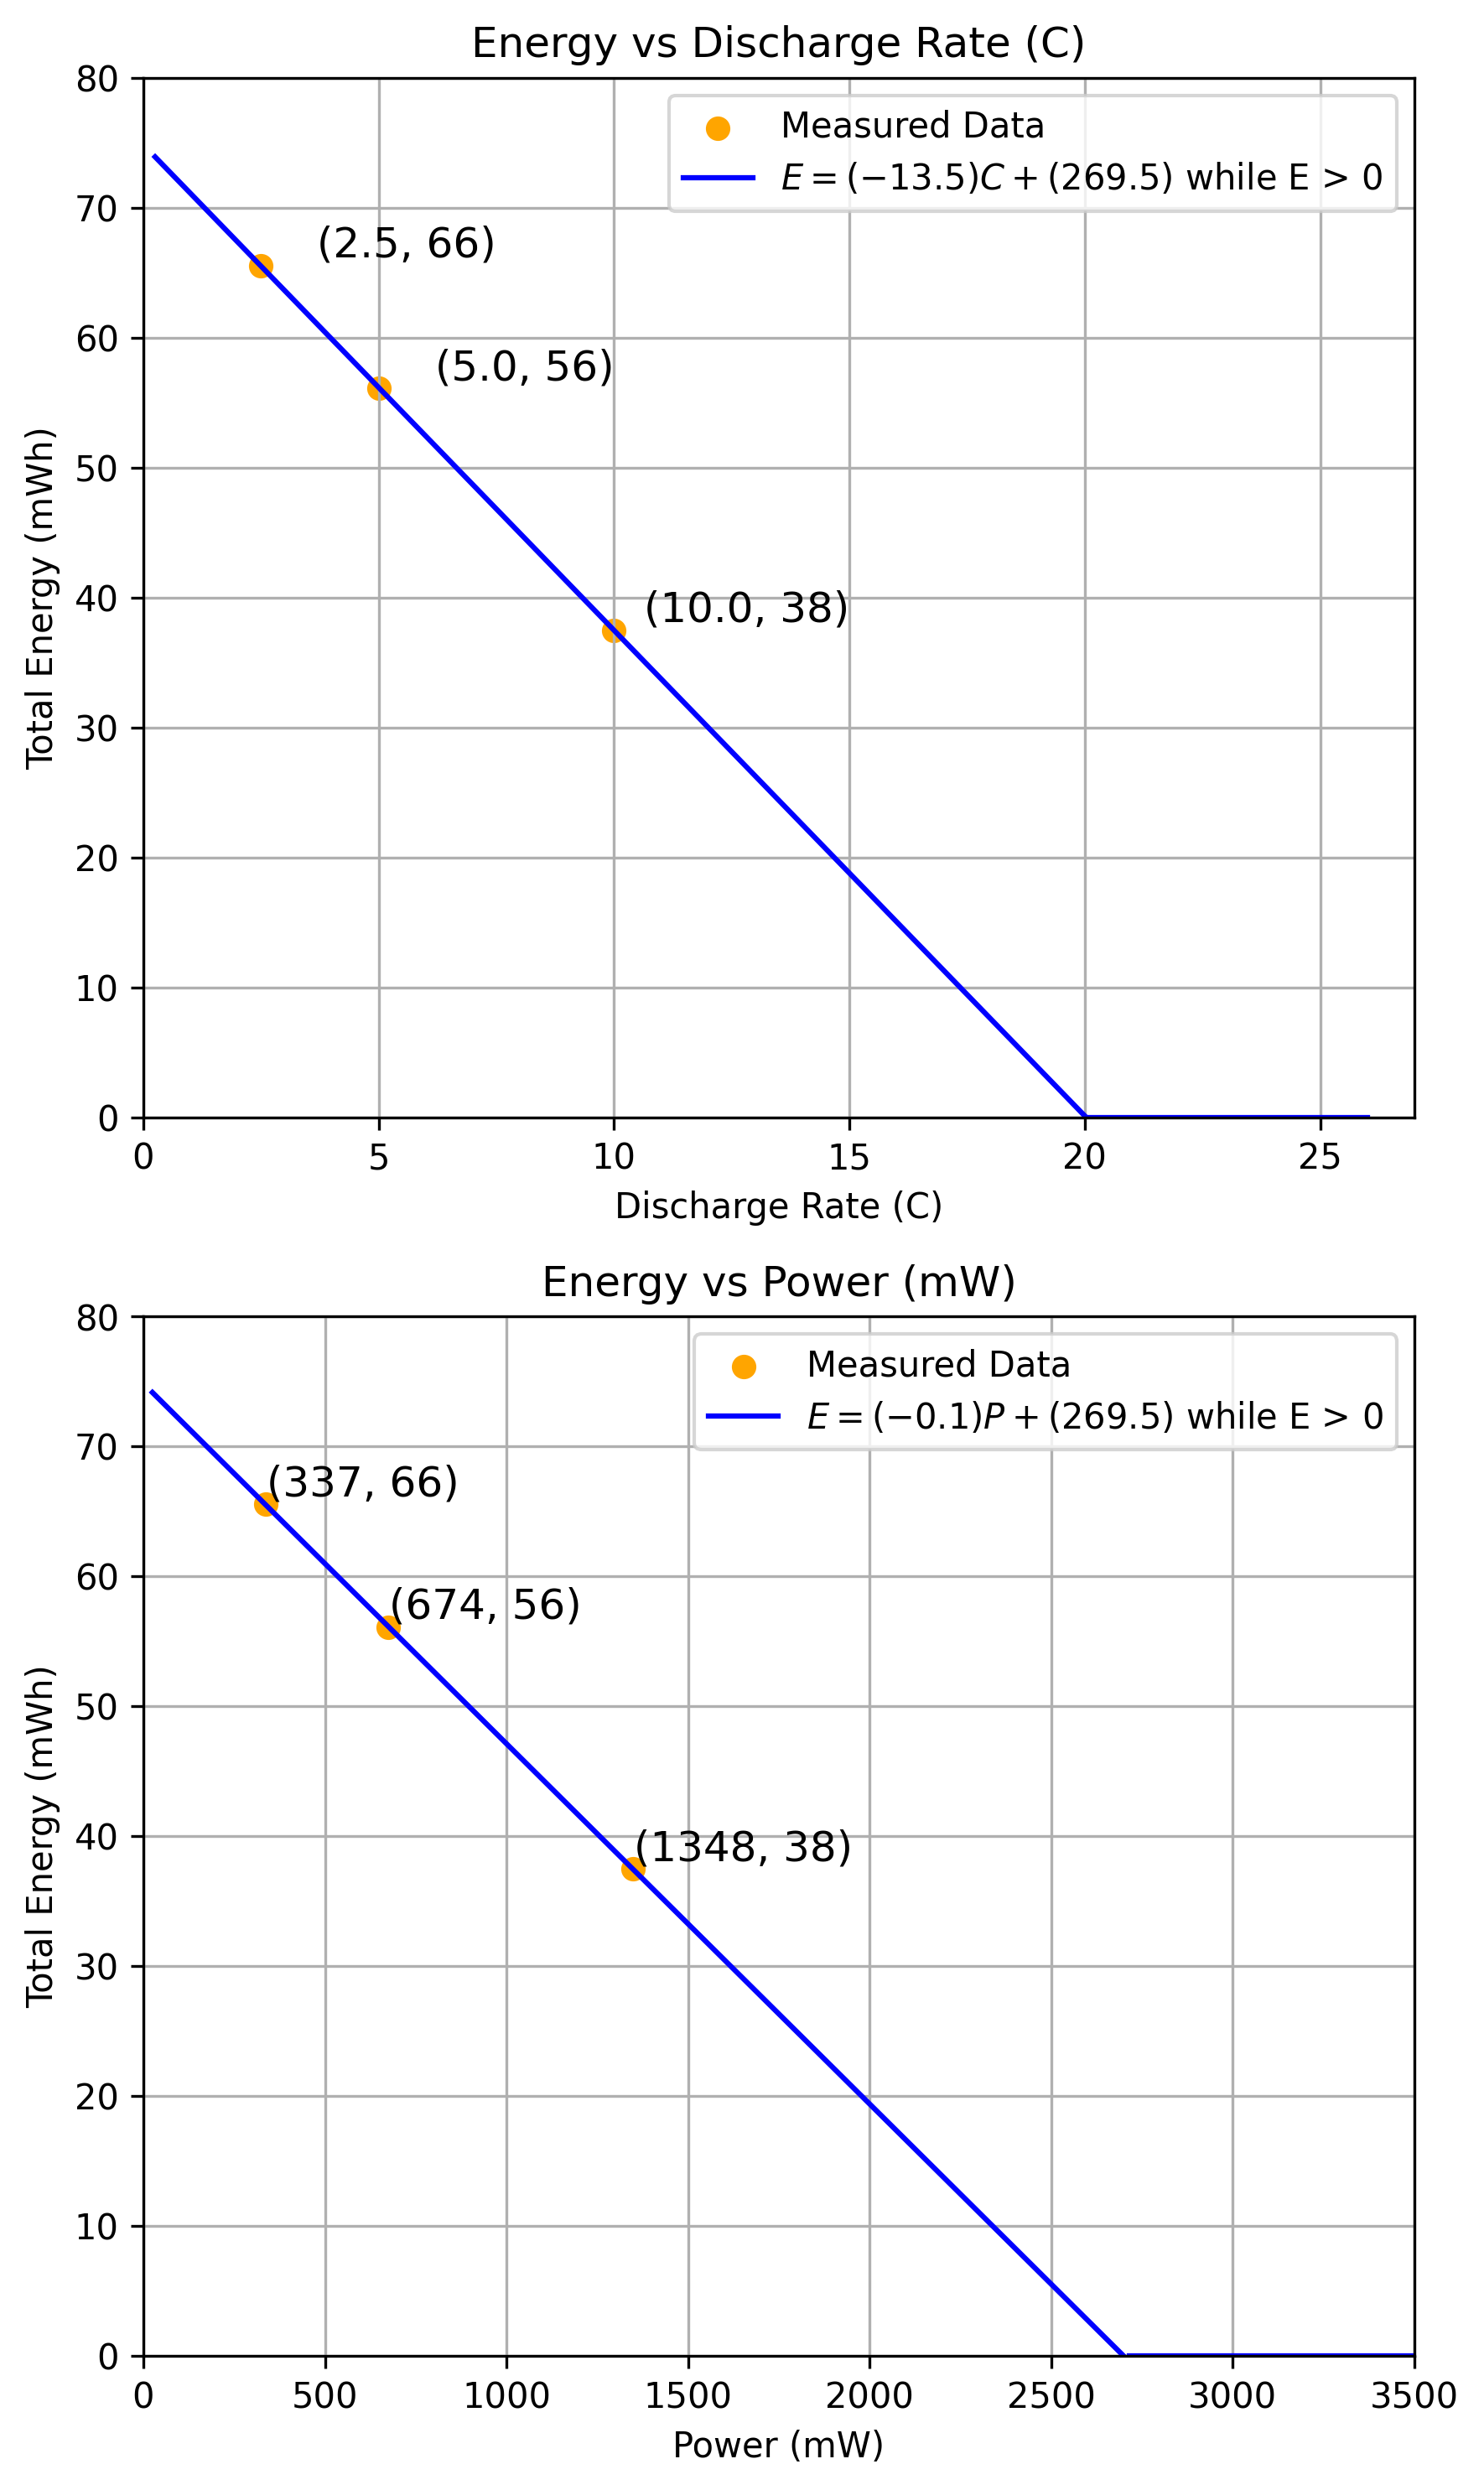

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# New data: 10c is 80mA discharge lasted 200 seconds for 80mg non-rechargeable battery
# Provided data for 465mg Battery
# Dia(mm)	Length(mm)	Vol(mm3)	Mass(mg)	Power(mW)
#  3	     6.4	      45.22	     70	       203
#  4	     7.7	      96.71	     150	     434
#  5	     15.3.     	300.26	   465	     1348
C_vals = np.array([2.5, 5, 10])
P_vals = np.array([337, 674, 1348])
time_vals = np.array([700, 300, 100])
E_measured_J = np.array([236, 202, 135])

# (Optional) verify energy from P·t
E_from_Pt = (P_vals * time_vals) / 1000  # should match E_measured_J

# --- 1) Compute linear fits ---
m_C, b_C = np.polyfit(C_vals, E_measured_J, 1)
m_P, b_P = np.polyfit(P_vals, E_measured_J, 1)

def E_c(c):
    return (m_C * c + b_C) / 3.6 # mWh
def E_p(p):
    return (m_P * p + b_P) / 3.6 # mWh

# find where each fit crosses zero
c_zero = -b_C / m_C
p_zero = -b_P / m_P

# Plot ranges
c_range = np.linspace(0.25, 26, 200)
p_range = np.linspace(25, 3525, 200)

fig, axs = plt.subplots(2, 1, figsize=(6, 10), dpi=300)

# Top: Energy vs C
mask_c_fit  = c_range <= c_zero
axs[0].scatter(C_vals, E_measured_J/3.6, label="Measured Data", color="orange")
for c, E in zip(C_vals, E_measured_J/3.6):
    axs[0].text(c+5, E, f"({c:.1f}, {E:.0f})", va='bottom', ha='right', fontsize=12)     # show (x, y)

# flat segment thereafter
mask_c_flat = c_range > c_zero
if mask_c_flat.any():
    axs[0].plot(c_range[mask_c_flat], np.zeros_like(c_range[mask_c_flat]),
                color="blue", linestyle="-")

axs[0].plot(c_range, E_c(c_range), label=f"$E=({m_C:.1f})C + ({b_C:.1f})$ while E > 0", color="blue")
axs[0].set_xlabel("Discharge Rate (C)")
axs[0].set_xlim(0, 27)
axs[0].set_ylabel("Total Energy (mWh)")
axs[0].set_ylim(0, 80)
axs[0].set_title("Energy vs Discharge Rate (C)")
axs[0].grid(True)
axs[0].legend()

# Bottom: Energy vs P
axs[1].scatter(P_vals, E_measured_J/3.6, label="Measured Data", color="orange")
for p, E in zip(P_vals, E_measured_J/3.6):
    axs[1].text(p+3, E, f"({p:.0f}, {E:.0f})", va='bottom', ha='left', fontsize=12)    # show (x, y)

# flat segment thereafter
mask_p_flat = p_range > p_zero
if mask_p_flat.any():
    axs[1].plot(p_range[mask_p_flat], np.zeros_like(p_range[mask_p_flat]), color="blue", linestyle="-")

axs[1].plot(p_range, E_p(p_range), label=f"$E=({m_P:.1f})P + ({b_P:.1f})$ while E > 0", color="blue")
axs[1].set_xlabel("Power (mW)")
axs[1].set_xlim(0, 3500)
axs[1].set_ylabel("Total Energy (mWh)")
axs[1].set_ylim(0, 80)
axs[1].set_title("Energy vs Power (mW)")
axs[1].grid(True)
axs[1].legend()
plt.tight_layout()
plt.show()

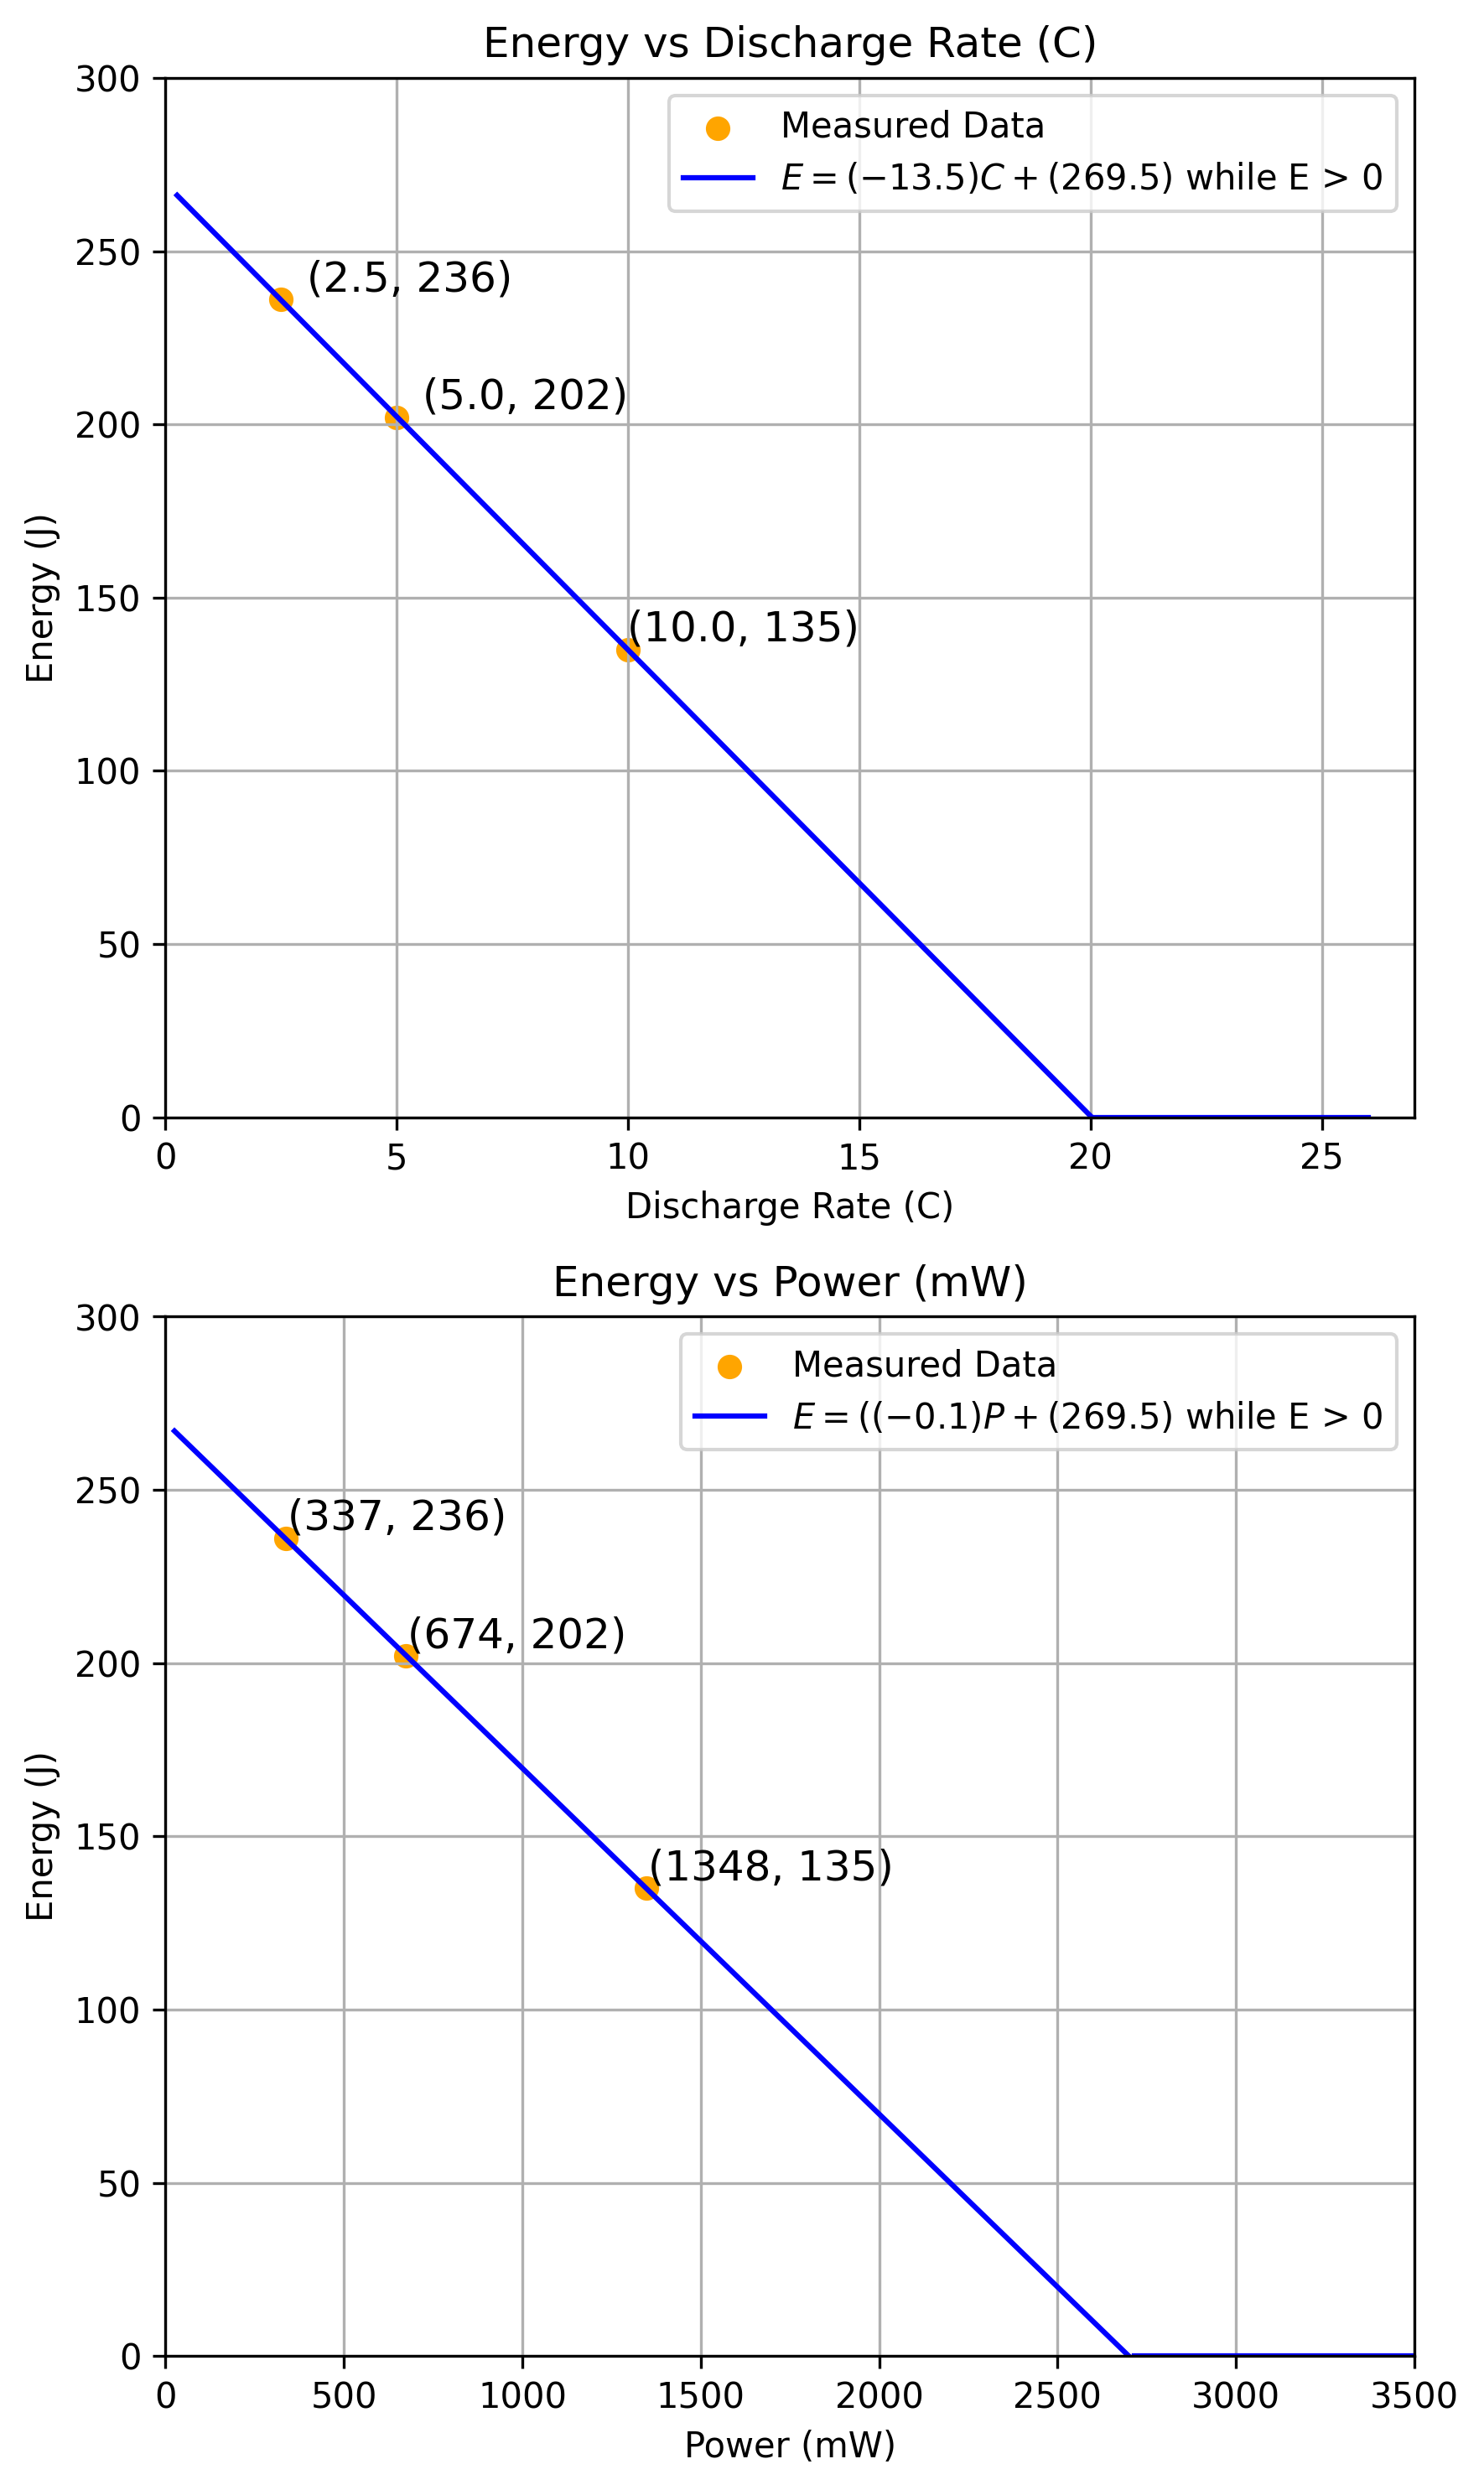

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Provided data
C_vals = np.array([2.5, 5, 10])
P_vals = np.array([337, 674, 1348])
time_vals = np.array([700, 300, 100])
E_measured_J = np.array([236, 202, 135])

# (Optional) verify energy from P·t
E_from_Pt = (P_vals * time_vals) / 1000  # should match E_measured_J

# --- 1) Compute linear fits ---
m_C, b_C = np.polyfit(C_vals, E_measured_J, 1)
m_P, b_P = np.polyfit(P_vals, E_measured_J, 1)

def E_c(c):
    return m_C * c + b_C
def E_p(p):
    return m_P * p + b_P

# find where each fit crosses zero
c_zero = -b_C / m_C
p_zero = -b_P / m_P

# Plot ranges
c_range = np.linspace(0.25, 26, 200)
p_range = np.linspace(25, 3525, 200)

fig, axs = plt.subplots(2, 1, figsize=(6, 10), dpi=300)

# Top: Energy vs C
mask_c_fit  = c_range <= c_zero
axs[0].scatter(C_vals, E_measured_J, label="Measured Data", color="orange")
for c, E in zip(C_vals, E_measured_J):
    axs[0].text(c+5, E, f"({c:.1f}, {E:.0f})", va='bottom', ha='right', fontsize=12)     # show (x, y)

# flat segment thereafter
mask_c_flat = c_range > c_zero
if mask_c_flat.any():
    axs[0].plot(c_range[mask_c_flat], np.zeros_like(c_range[mask_c_flat]),
                color="blue", linestyle="-")

axs[0].plot(c_range, E_c(c_range), label=f"$E=({m_C:.1f})C + ({b_C:.1f})$ while E > 0", color="blue")
axs[0].set_xlabel("Discharge Rate (C)")
axs[0].set_xlim(0, 27)
axs[0].set_ylabel("Energy (J)")
axs[0].set_ylim(0, 300)
axs[0].set_title("Energy vs Discharge Rate (C)")
axs[0].grid(True)
axs[0].legend()

# Bottom: Energy vs P
axs[1].scatter(P_vals, E_measured_J, label="Measured Data", color="orange")
for p, E in zip(P_vals, E_measured_J):
    axs[1].text(p+5, E, f"({p:.0f}, {E:.0f})", va='bottom', ha='left', fontsize=12)    # show (x, y)

# flat segment thereafter
mask_p_flat = p_range > p_zero
if mask_p_flat.any():
    axs[1].plot(p_range[mask_p_flat], np.zeros_like(p_range[mask_p_flat]), color="blue", linestyle="-")

axs[1].plot(p_range, E_p(p_range), label=f"$E=(({m_P:.1f})P + ({b_P:.1f})$ while E > 0", color="blue")
axs[1].set_xlabel("Power (mW)")
axs[1].set_xlim(0, 3500)
axs[1].set_ylabel("Energy (J)")
axs[1].set_ylim(0, 300)
axs[1].set_title("Energy vs Power (mW)")
axs[1].grid(True)
axs[1].legend()
plt.tight_layout()
plt.show()

## Lift vs Power Plots NEW DATA

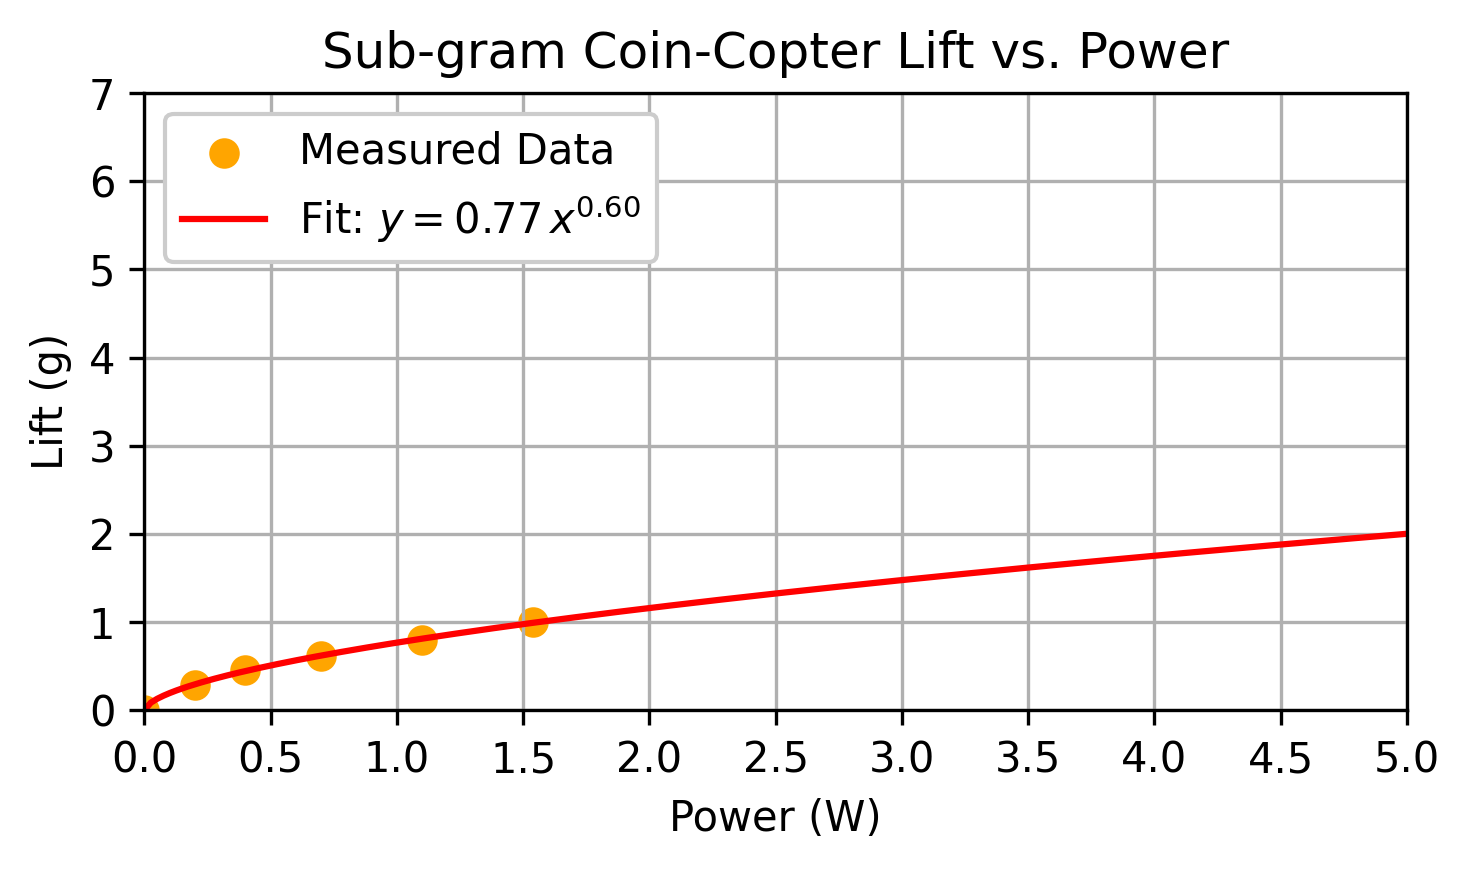

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Power (W) and Lift (g) data
power = np.array([1.54, 1.1, 0.7, 0.4, 0.2, 0])
lift  = np.array([1.00, 0.8, 0.61, 0.46, 0.29, 0])

# Define the non-linear model: a * P^b
def power_law(P, a, b):
    return a * P**b

# Initial guesses for [a, b]
p0 = [1.0, 1.0]

# Perform the curve fit
popt, pcov = curve_fit(power_law, power, lift, p0=p0)
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))  # one‐sigma errors on the parameters

# Generate smooth curve for plotting
P_smooth = np.linspace(power.min(), power.max(), 100)
lift_fit  = power_law(P_smooth, a_fit, b_fit)

# Plotting
P_smooth = np.linspace(0., 5.0, 200)
lift_fit  = power_law(P_smooth, a_fit, b_fit)

plt.figure(figsize=(5,3), dpi=300)
plt.scatter(power, lift, color="orange", label="Measured Data", s=40)
plt.plot(
    P_smooth, lift_fit, color='red',
    label=(
        rf"Fit: $y={a_fit:.2f}\,x^{{{b_fit:.2f}}}$"
        #f"\n({a_fit:.2f}±{perr[0]:.2f}, {b_fit:.2f}±{perr[1]:.2f})"
    )
)
plt.xlabel("Power (W)")
plt.xlim(0., 5.0)
plt.xticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.ylabel("Lift (g)")
plt.ylim(0, 7)
plt.title("Sub-gram Coin-Copter Lift vs. Power")
plt.grid(True)
plt.legend(loc='upper left',facecolor='white', framealpha=1,)
plt.tight_layout()
plt.show()

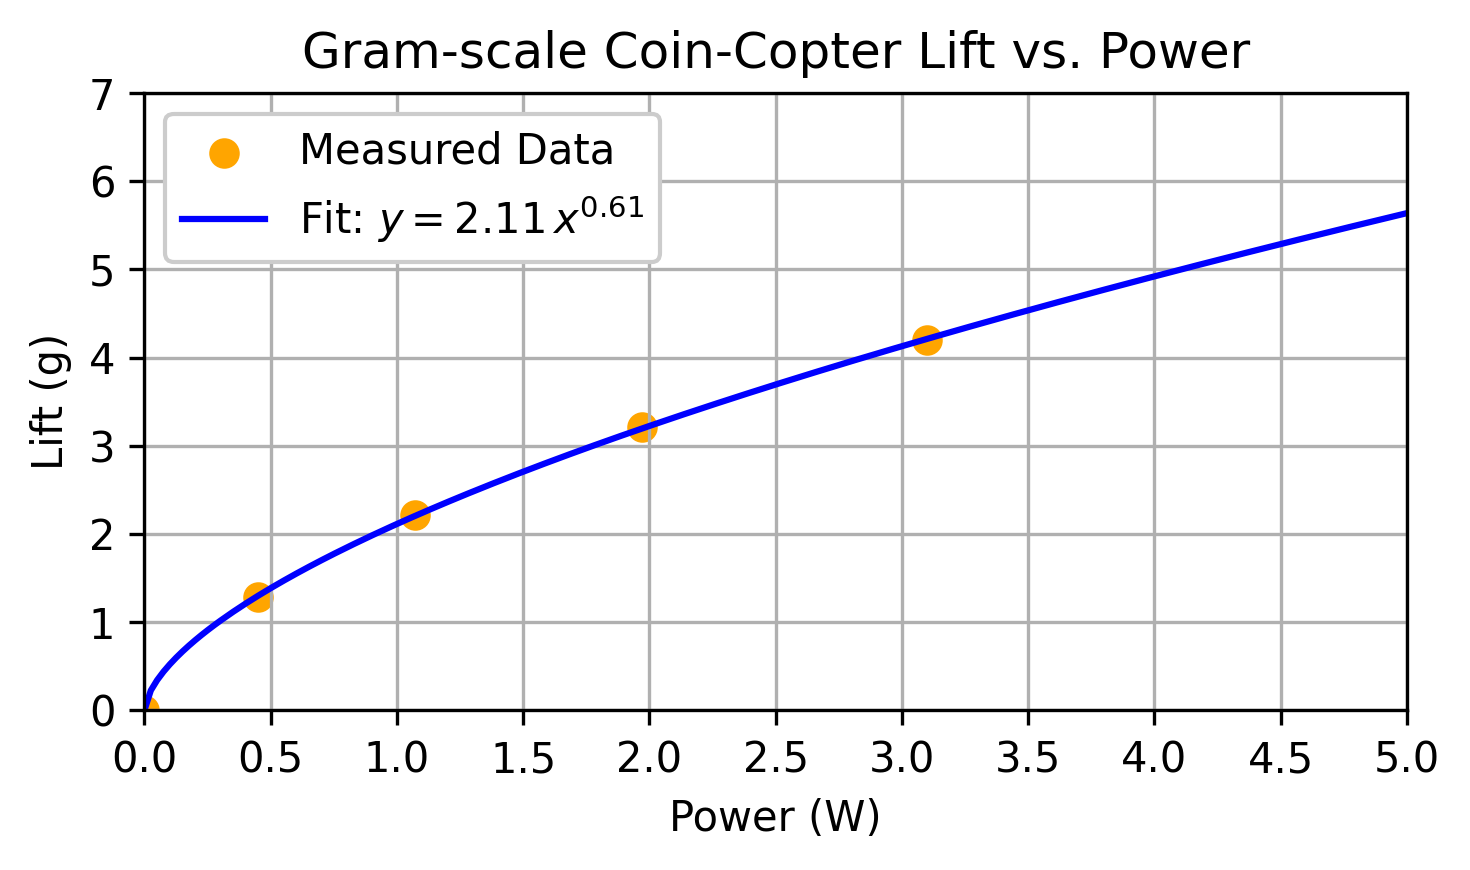

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Power (W) and Lift (g) data
power = np.array([3.10, 1.97, 1.07, 0.45, 0]) # 5V, 4V, 3V, 2V
lift  = np.array([4.20, 3.21, 2.21, 1.28, 0])

# Define the non-linear model: a * P^b
def power_law(P, a, b):
    return a * P**b

# Initial guesses for [a, b]
p0 = [1.0, 1.0]

# Perform the curve fit
popt, pcov = curve_fit(power_law, power, lift, p0=p0)
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))  # one‐sigma errors on the parameters

# Generate smooth curve for plotting
P_smooth = np.linspace(power.min(), power.max(), 100)
lift_fit  = power_law(P_smooth, a_fit, b_fit)

# Plotting
P_smooth = np.linspace(0., 5.0, 200)
lift_fit  = power_law(P_smooth, a_fit, b_fit)

plt.figure(figsize=(5,3), dpi=300)
plt.scatter(power, lift, color="orange", label="Measured Data", s=40)
plt.plot(
    P_smooth, lift_fit, color='blue',
    label=(
        rf"Fit: $y={a_fit:.2f}\,x^{{{b_fit:.2f}}}$"
        #f"\n({a_fit:.2f}±{perr[0]:.2f}, {b_fit:.2f}±{perr[1]:.2f})"
    )
)
plt.xlabel("Power (W)")
plt.xlim(0, 5)
plt.xticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.ylabel("Lift (g)")
plt.ylim(0, 7)
plt.title("Gram-scale Coin-Copter Lift vs. Power")
plt.grid(True)
plt.legend(loc='upper left',facecolor='white', framealpha=1,)
plt.tight_layout()
plt.show()

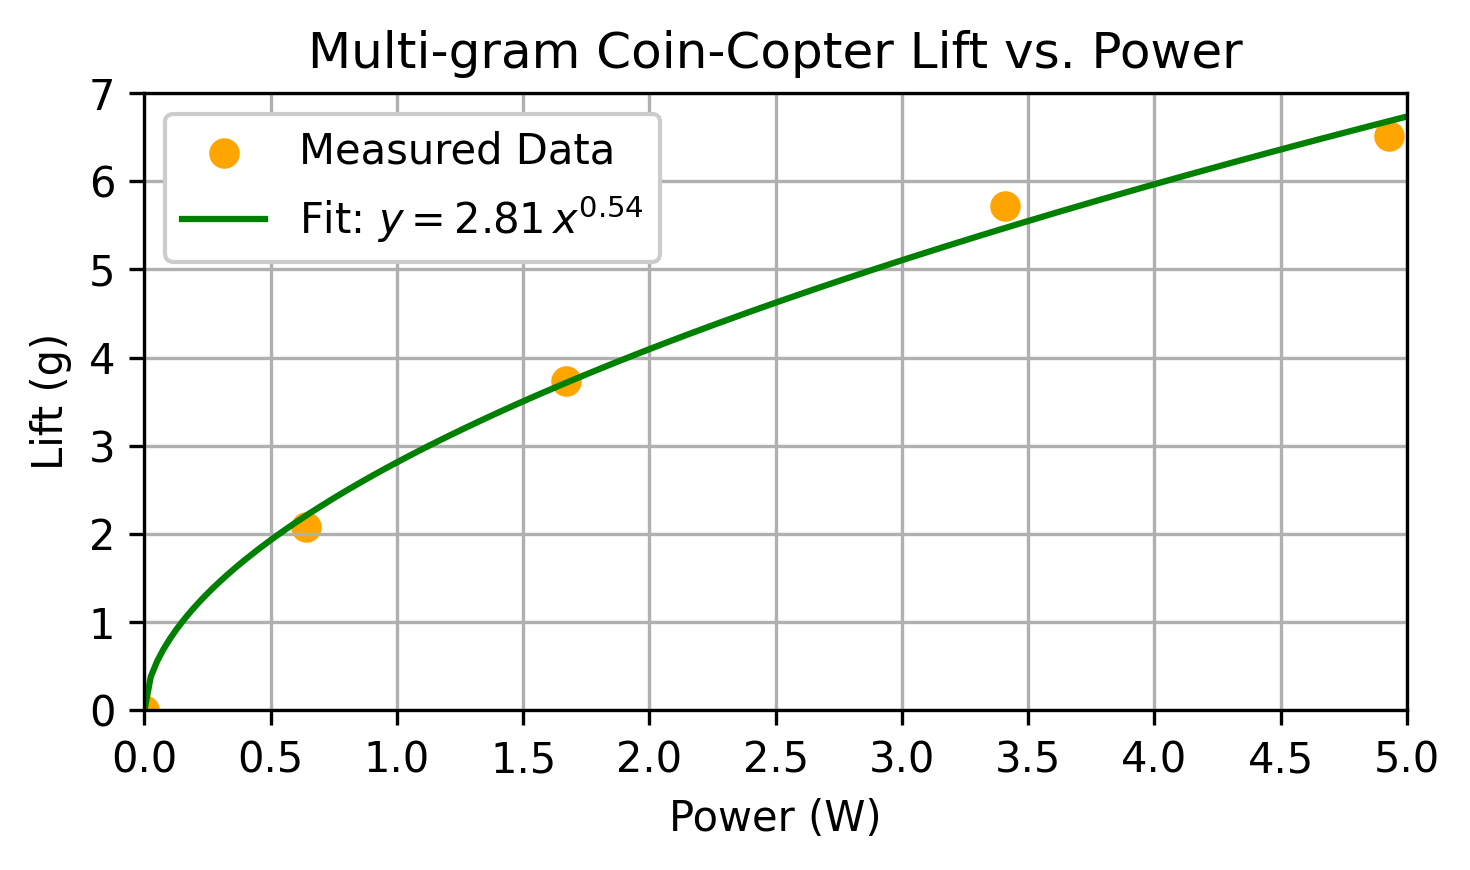

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Power (W) and Lift (g) data
power = np.array([4.93, 3.41, 1.67, 0.64, 0])
lift  = np.array([6.51,  5.72,  3.73,  2.08, 0])

# Define the non-linear model: a * P^b
def power_law(P, a, b):
    return a * P**b

# Initial guess for [a, b]
p0 = [1.0, 1.0]

# Perform the curve fit
popt, pcov = curve_fit(power_law, power, lift, p0=p0)
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))  # 1-σ parameter errors

# Create a smooth P range for plotting the fit
P_smooth = np.linspace(0., 5, 200)
lift_fit = power_law(P_smooth, a_fit, b_fit)

# Plot
plt.figure(figsize=(5,3), dpi=300)
plt.scatter(power, lift, color="orange", label="Measured Data", s=40)
plt.plot(
    P_smooth, lift_fit, color='green',
    label=(
        rf"Fit: $y={a_fit:.2f}\,x^{{{b_fit:.2f}}}$"
        #f"\n({a_fit:.2f}±{perr[0]:.2f}, {b_fit:.2f}±{perr[1]:.2f})"
    )
)
plt.xlabel("Power (W)")
plt.xlim(0, 5)
plt.xticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.ylabel("Lift (g)")
plt.ylim(0, 7)
plt.title("Multi-gram Coin-Copter Lift vs. Power")
plt.grid(True)
plt.legend(loc='upper left',facecolor='white', framealpha=1,)
plt.tight_layout()
plt.show()

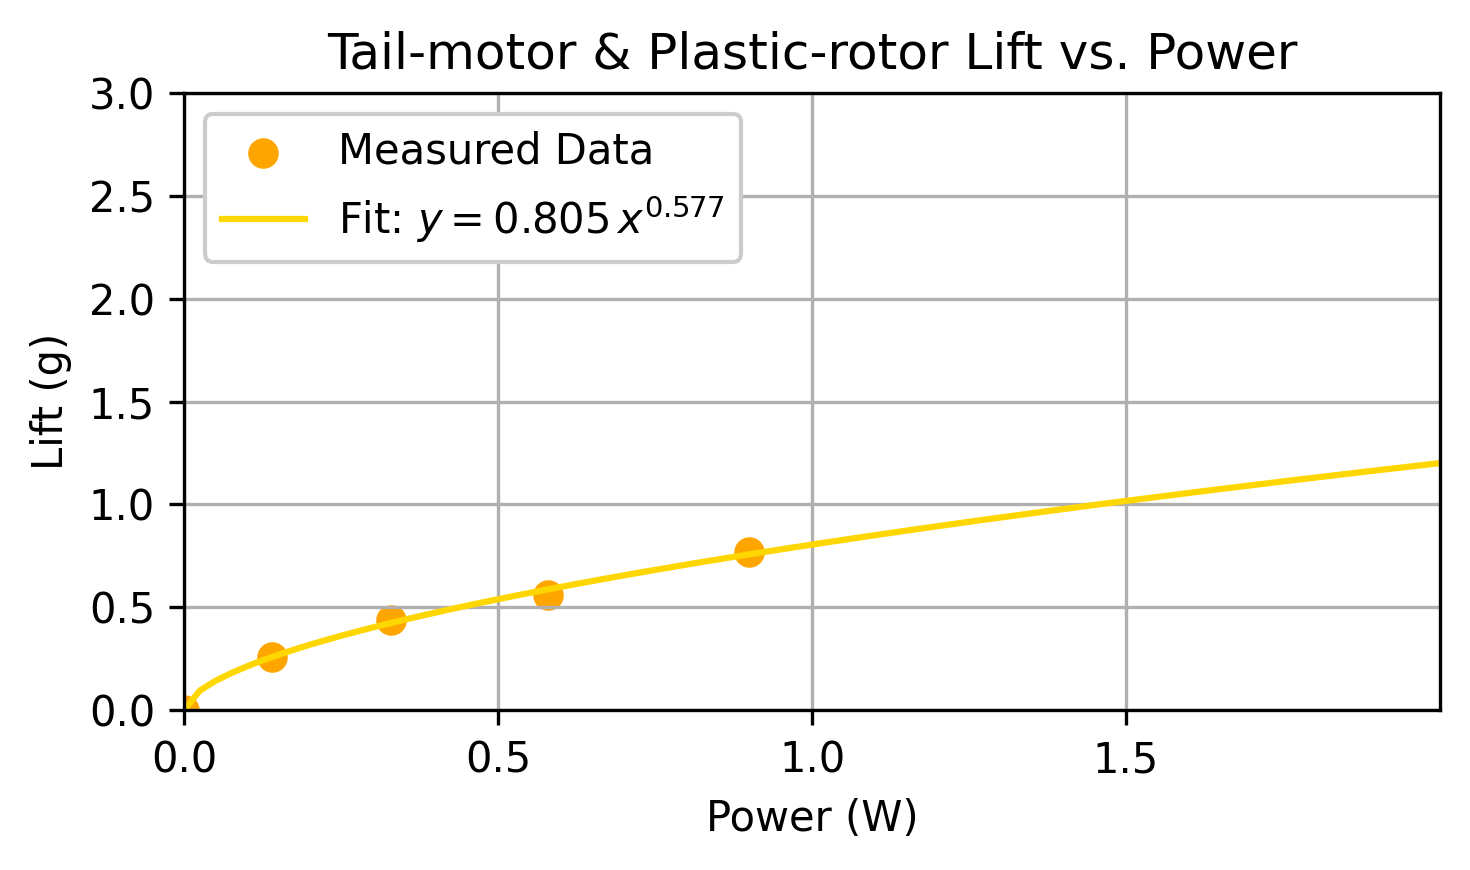

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Power (W) and Lift (g) data
power = np.array([0.90, 0.58, 0.33, 0.14, 0])
lift  = np.array([0.77, 0.56, 0.44, 0.26, 0])

# Define the non-linear model: a * P^b
def power_law(P, a, b):
    return a * P**b

# Initial guesses for [a, b]
p0 = [1.0, 1.0]

# Perform the curve fit
popt, pcov = curve_fit(power_law, power, lift, p0=p0)
a_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))  # one‐sigma errors on the parameters

# Generate smooth curve for plotting
P_smooth = np.linspace(power.min(), power.max(), 100)
lift_fit  = power_law(P_smooth, a_fit, b_fit)

# Plotting
P_smooth = np.linspace(0., 5.0, 200)
lift_fit  = power_law(P_smooth, a_fit, b_fit)

plt.figure(figsize=(5,3), dpi=300)
plt.scatter(power, lift, color="orange", label="Measured Data", s=40)
plt.plot(
    P_smooth, lift_fit, color='gold',
    label=(
        rf"Fit: $y={a_fit:.3f}\,x^{{{b_fit:.3f}}}$"
        #f"\n({a_fit:.2f}±{perr[0]:.2f}, {b_fit:.2f}±{perr[1]:.2f})"
    )
)
plt.xlabel("Power (W)")
plt.xlim(0., 2.0)
plt.xticks([0, 0.5, 1, 1.5]) #, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.ylabel("Lift (g)")
plt.ylim(0, 3)
plt.title("Tail-motor & Plastic-rotor Lift vs. Power")
plt.grid(True)
plt.legend(loc='upper left',facecolor='white', framealpha=1,)
plt.tight_layout()
plt.show()